# Amazon Review Dataset

## Week 2 - Linear Regression

In [1]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [2]:
df = pd.read_csv("../dataset/cleaned_amazon_review.csv")

In [3]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","purchased this for my device, it worked as adv...",5.0,moar space!!!,1382659200,2013-10-25,409,0,0
1,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. i should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
2,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",this think has worked out great.had a diff. br...,5.0,great buy at this price!!! *** update,1384992000,2013-11-21,382,0,0
3,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","bought it with retail packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0
4,A2IDCSC6NVONIZ,B007WTAJTO,2Cents!,"[0, 0]",it's mini storage. it doesn't do anything els...,5.0,not a lot to really be said,1367193600,2013-04-29,588,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4913 entries, 0 to 4912
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      4913 non-null   str    
 1   asin            4913 non-null   str    
 2   reviewerName    4913 non-null   str    
 3   helpful         4913 non-null   str    
 4   reviewText      4913 non-null   str    
 5   overall         4913 non-null   float64
 6   summary         4913 non-null   str    
 7   unixReviewTime  4913 non-null   int64  
 8   reviewTime      4913 non-null   str    
 9   day_diff        4913 non-null   int64  
 10  helpful_yes     4913 non-null   int64  
 11  total_vote      4913 non-null   int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 460.7 KB


In [5]:
X = df[
    [
        "helpful_yes",
        "total_vote",
        "day_diff",
    ]
]

In [6]:
df.describe()

,overall,unixReviewTime,day_diff,helpful_yes,total_vote
count,4913.000000,4.913000e+03,4913.000000,4913.000000,4913.000000
mean,4.587625,1.379466e+09,437.346224,1.311215,1.521474
std,0.996995,1.580982e+07,209.360537,41.627627,44.132066
min,1.000000,1.339200e+09,1.000000,0.000000,0.000000
25%,5.000000,1.365898e+09,281.000000,0.000000,0.000000
50%,5.000000,1.381277e+09,431.000000,0.000000,0.000000
75%,5.000000,1.392163e+09,601.000000,0.000000,0.000000
max,5.000000,1.405296e+09,1064.000000,1952.000000,2020.000000


In [7]:
y = df["overall"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [9]:
model = LinearRegression()

In [10]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.03,-0.03,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['helpful_yes','total_vote','day_diff']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.77
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [11]:
y_pred = model.predict(X_test)

In [12]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2  :", r2_score(y_test, y_pred))

MAE : 0.6628035325780238
MSE : 1.0392301784102278
R2  : 0.0006760138904298163


In [13]:
results = pd.DataFrame(
    {
        "Actual Rating": y_test.values,
        "Predicted Rating": y_pred,
    }
)

results.head(10)

,Actual Rating,Predicted Rating
0,5.0,4.592449
1,5.0,4.575215
2,5.0,4.579624
3,5.0,4.681824
4,4.0,4.611687
5,5.0,4.705471
6,5.0,4.523088
7,5.0,4.472214
8,4.0,4.650162
9,5.0,4.645353


In [14]:
coefficients = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": model.coef_,
    }
)

coefficients

,Feature,Coefficient
0,helpful_yes,0.025042
1,total_vote,-0.025274
2,day_diff,-0.000401


In [15]:
joblib.dump(
    model,
    "../models/linear_regression_model.pkl",
)

['../models/linear_regression_model.pkl']

Matplotlib is building the font cache; this may take a moment.


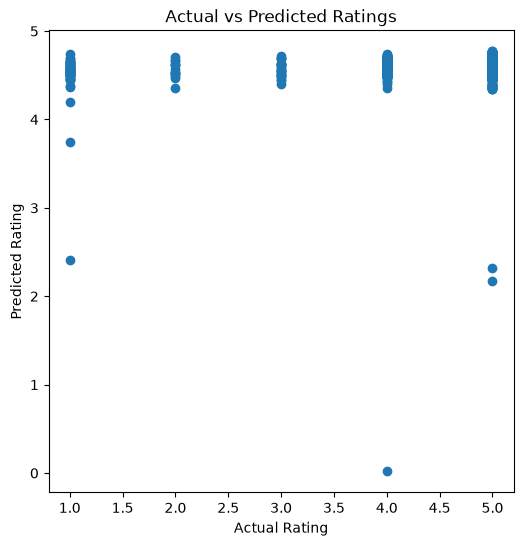

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()

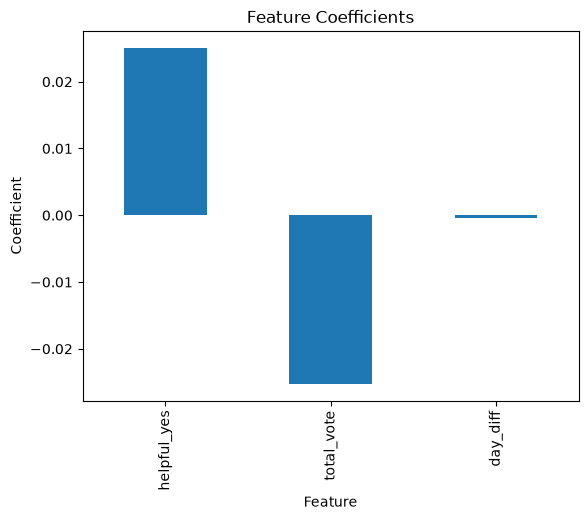

In [17]:
coefficients.plot(
    x="Feature",
    y="Coefficient",
    kind="bar",
    legend=False,
    title="Feature Coefficients"
)

plt.ylabel("Coefficient")
plt.show()

In [18]:
print("Week 2 completed successfully.")

Week 2 completed successfully.
